Covariance shape: (144, 144)


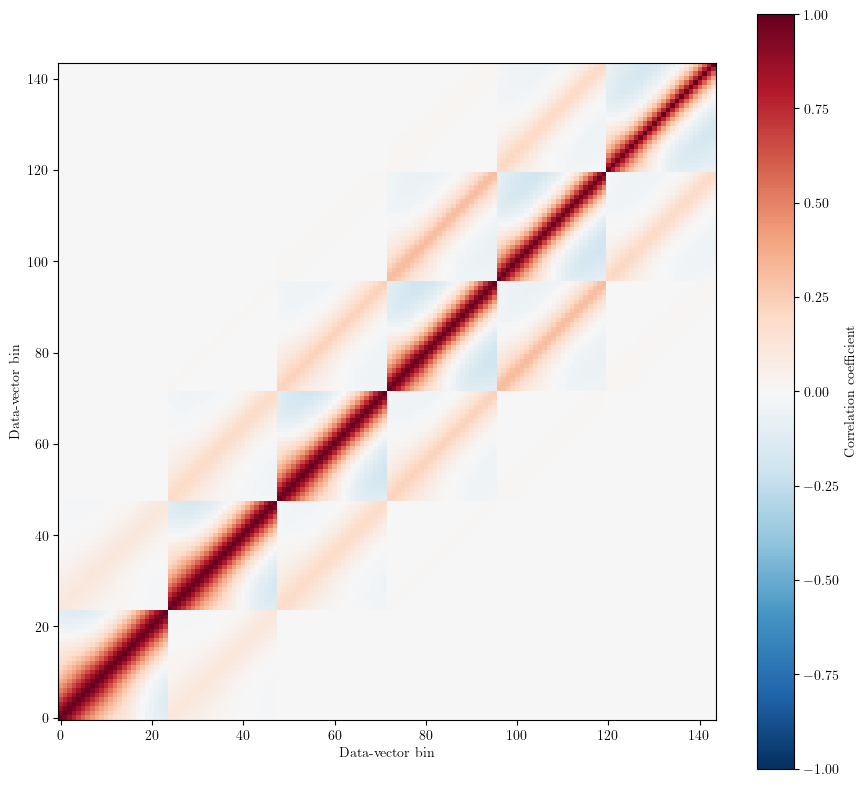

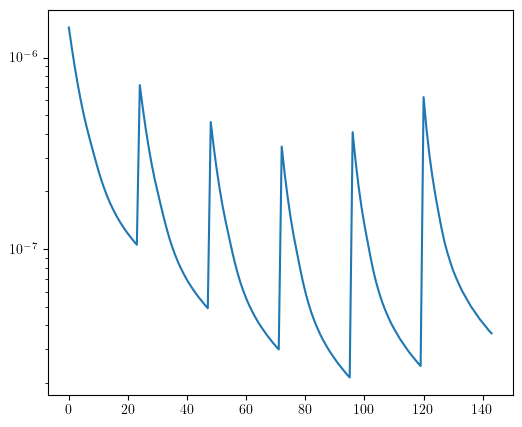

In [1]:
import os
os.environ["PATH"] = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

# ------------------------------------------------------------
# Load covariance matrix
# ------------------------------------------------------------

filename = f"cov_tjpcov/cov_wtheta_DESY6BAO.txt"

cov = np.loadtxt(filename)

print("Covariance shape:", cov.shape)

# ------------------------------------------------------------
# Convert covariance -> correlation matrix
# ------------------------------------------------------------

std = np.sqrt(np.diag(cov))

corr = cov / np.outer(std, std)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    corr,
    origin="lower",
    interpolation="none",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient")

ax.set_xlabel("Data-vector bin")
ax.set_ylabel("Data-vector bin")

plt.tight_layout()

fig, ax = plt.subplots(figsize=(6, 5))

ax.semilogy(np.diag(cov))
